# Step 1: Importing Data Set

In [1]:
from tensorflow.keras.datasets import fashion_mnist

# Load Dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Check Dataset Shape
print("Training Images Shape :", X_train.shape)
print("Training Labels Shape :", y_train.shape)

print("Testing Images Shape  :", X_test.shape)
print("Testing Labels Shape  :", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 30s 1us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 4s 1us/step
Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape  : (10000, 28, 28)
Testing Labels Shape  : (10000,)


# Step 2: Understanding Dataset

In [2]:
class_names = [
    'T-Shirt/Top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle Boot'
]

print(class_names)

['T-Shirt/Top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']


# Step 3: Display First Image

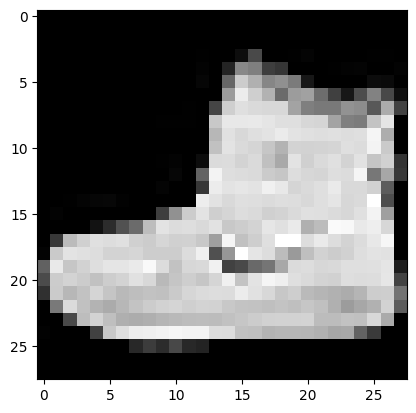

In [3]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0], cmap='gray')
plt.show()

# Step 4: Display Image with Label

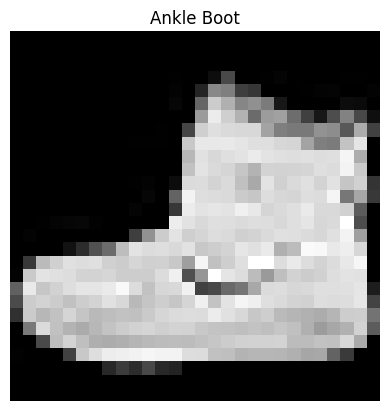

In [4]:
plt.imshow(X_train[0], cmap='gray')
plt.title(class_names[y_train[0]])
plt.axis('off')
plt.show()

# Step 5: Display Multiple Images

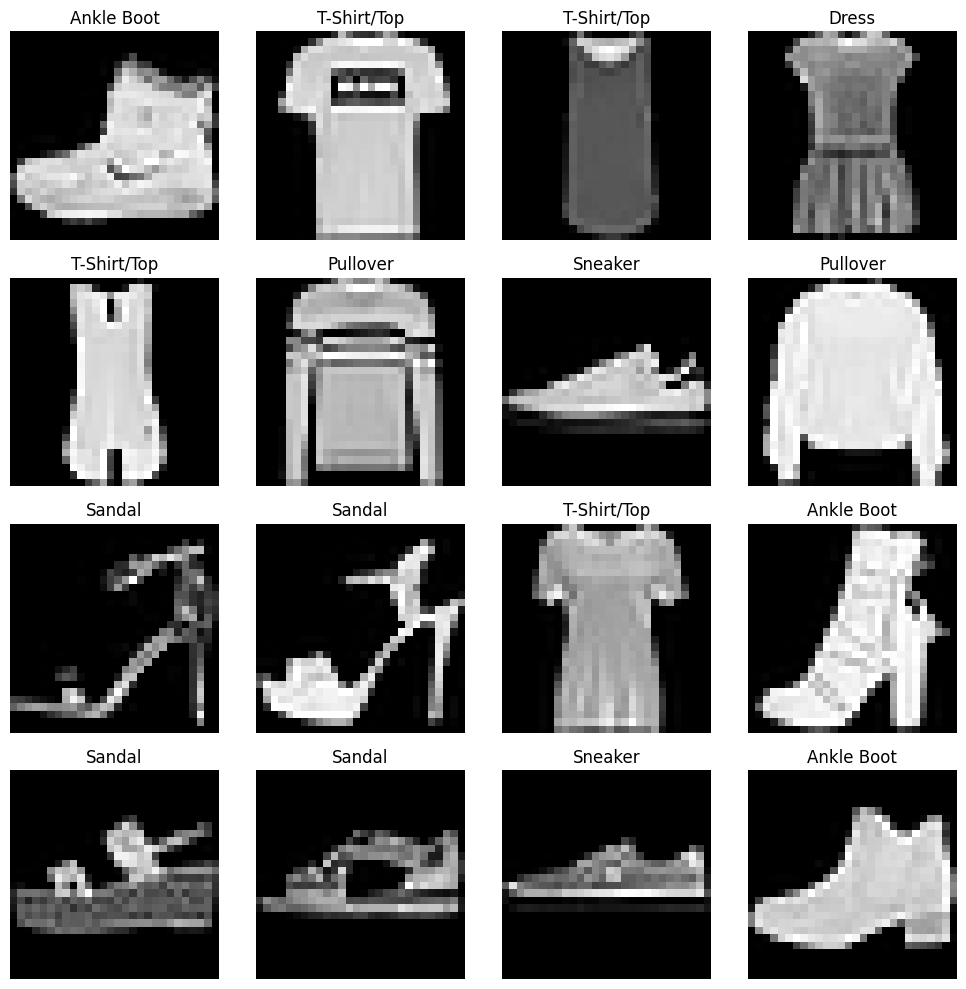

In [5]:
plt.figure(figsize=(10,10))

for i in range(16):
    
    plt.subplot(4,4,i+1)
    
    plt.imshow(X_train[i], cmap='gray')
    
    plt.title(class_names[y_train[i]])
    
    plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
print(y_train[:10])

[9 0 0 3 0 2 7 2 5 5]


In [7]:
print("First Label:", y_train[0])
print("Second Label:", y_train[1])
print("Third Label:", y_train[2])

First Label: 9
Second Label: 0
Third Label: 0


# Step 6: Data Preprocessing

In [8]:
# Normalize Pixel Values

X_train = X_train / 255.0
X_test = X_test / 255.0

In [9]:
print("Minimum Value:", X_train.min())
print("Maximum Value:", X_train.max())

Minimum Value: 0.0
Maximum Value: 1.0


# Step 7: Flatten the Images

In [11]:
# Reshape Images

X_train = X_train.reshape(60000, 784)

X_test = X_test.reshape(10000, 784)

In [12]:
print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (60000, 784)
Testing Shape : (10000, 784)


# Step 8: Building ANN Model

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

# Build ANN Model
model = Sequential([

    Dense(128, activation='relu', input_shape=(784,)),

    BatchNormalization(),

    Dropout(0.3),

    Dense(64, activation='relu'),

    BatchNormalization(),

    Dropout(0.3),

    Dense(10, activation='softmax')

])

C:\Users\Digital\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 110,154 (430.29 KB)

 Trainable params: 109,770 (428.79 KB)

 Non-trainable params: 384 (1.50 KB)

# Step 9: Compile Model

In [15]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Step 10: Model Training

In [16]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.7680 - loss: 0.6663 - val_accuracy: 0.8298 - val_loss: 0.4745
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8137 - loss: 0.5233 - val_accuracy: 0.8349 - val_loss: 0.4386
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8275 - loss: 0.4822 - val_accuracy: 0.8435 - val_loss: 0.4173
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8314 - loss: 0.4734 - val_accuracy: 0.8501 - val_loss: 0.4144
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.8405 - loss: 0.4484 - val_accuracy: 0.8600 - val_loss: 0.3883
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8438 - loss: 0.4373 - val_accuracy: 0.8672 - val_loss: 0.3613
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.8493 - loss: 0.4255 - val_accuracy: 0.8653 - val_loss: 0.3676
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8518 - 

# Step 10: Model Evaluation

In [17]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8651 - loss: 0.3691
Test Loss: 0.3690546154975891
Test Accuracy: 0.8651000261306763


# Step 11: Make Predictions

In [18]:
predictions = model.predict(X_test)

print(predictions.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
(10000, 10)


# Step 12: Converting Probabilities into Predictions

In [19]:
import numpy as np

predicted_labels = np.argmax(predictions, axis=1)

print(predicted_labels[:10])

[9 2 1 1 6 1 4 6 5 7]


# Step 13: Compare Actual vs Predicted

In [20]:
for i in range(10):
    print("Actual:", y_test[i],
          "Predicted:", predicted_labels[i])

Actual: 9 Predicted: 9
Actual: 2 Predicted: 2
Actual: 1 Predicted: 1
Actual: 1 Predicted: 1
Actual: 6 Predicted: 6
Actual: 1 Predicted: 1
Actual: 4 Predicted: 4
Actual: 6 Predicted: 6
Actual: 5 Predicted: 5
Actual: 7 Predicted: 7


# Step 14: Visualize Predictions

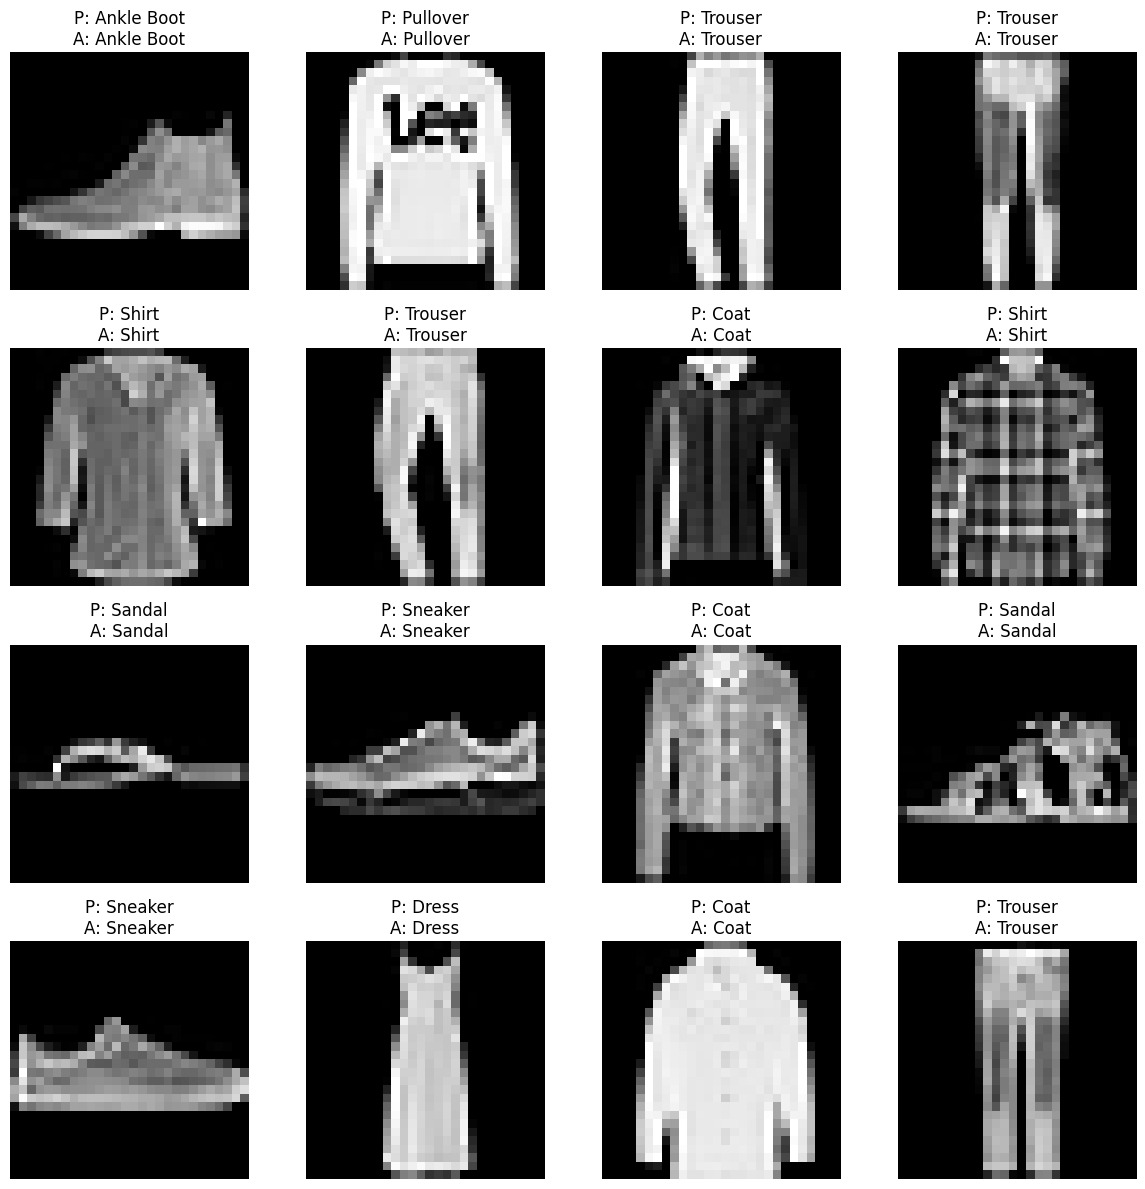

In [21]:
plt.figure(figsize=(12,12))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(X_test[i].reshape(28,28),
               cmap='gray')

    plt.title(
        f"P: {class_names[predicted_labels[i]]}\nA: {class_names[y_test[i]]}"
    )

    plt.axis('off')

plt.tight_layout()

plt.show()

# Step 15: Confusion Matrix

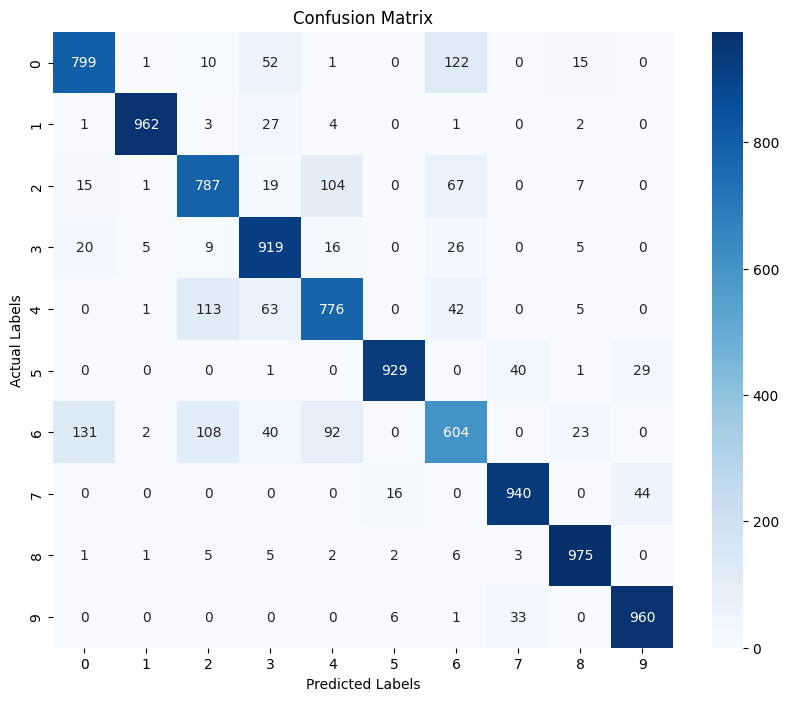

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.title("Confusion Matrix")

plt.show()

# Step 16: Plot Training History

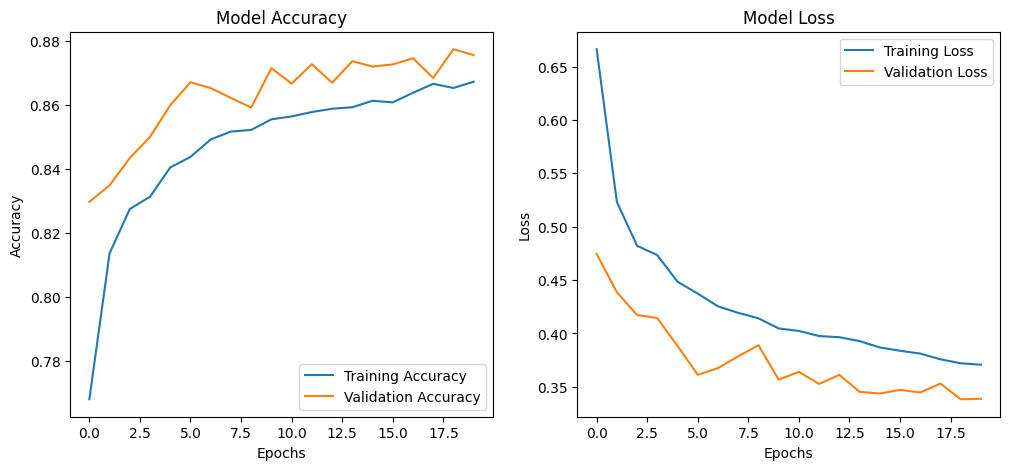

In [24]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()